# Prétraitement de l'audio

L'exécution de ce notebook a pour prérequis :
- Le téléchargement du dataset `GuitarSet`,
- le démarrage de l'infrastructure docker,
- l'ingestion du dataset `GuitarSet`.

Pour télécharger le dataset `GuitarSet`, utilisez la commande :
```bash
uv run ./audio_midi/main.py --download_datasets --no_idmt_smt_guitar
```

Pour démarrer l'infrastructure docker, utilisez la commande :
```bash
docker-compose up -d
```

Pour lancer la pipeline d'ingestion, utilisez la commande :
```bash
uv run ./audio_midi/main.py --ingest_guitar_set
```

## Imports

In [1]:
import sys
from pathlib import Path

AUDIO_MIDI_DIRECTORY = Path.cwd().parent
sys.path.append(AUDIO_MIDI_DIRECTORY.as_posix())

In [2]:
# Chemins
OUTPUT_DIRECTORY = AUDIO_MIDI_DIRECTORY / "output"
PREPROCESSING_DIRECTORY = OUTPUT_DIRECTORY / "preprocessing"
FIGURES_DIRECTORY = PREPROCESSING_DIRECTORY / "figures"

OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
PREPROCESSING_DIRECTORY.mkdir(parents=True, exist_ok=True)
FIGURES_DIRECTORY.mkdir(parents=True, exist_ok=True)

In [3]:
# Imports EDA
import numpy as np

In [4]:
# Imports graphiques
import matplotlib.pyplot as plt
import seaborn as sns

# Accessibilité : Daltonisme, Dyslexie, Confort Visuel
sns.set_theme(
    style="whitegrid",
    palette="colorblind",
    context="notebook",
)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.family": "Arial",
        "font.size": 12,
        "axes.titlesize": 15,
        "axes.titleweight": "bold",
        "axes.labelsize": 13,
        "axes.labelweight": "medium",
        "axes.edgecolor": "black",
        "axes.linewidth": 1.2,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "lines.linewidth": 2.2,
        "lines.markersize": 7,
        "legend.fontsize": 11,
        "legend.frameon": True,
        "legend.framealpha": 0.95,
        "grid.linestyle": ":",
        "grid.linewidth": 0.8,
        "grid.alpha": 0.6,
    }
)

COLORBLIND_PALETTE = sns.color_palette("colorblind")

In [5]:
# Imports storages
import logging
from settings import MINIO_SETTINGS
from src.storages import MinIOStorage

minio = MinIOStorage(logger=logging.getLogger())

c:\Users\Administrateur\Documents\M2i_CDSD_Projet\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Chargement d'un audio

In [6]:
title = "00_BN1-129-Eb_comp"
audio_data, sample_rate = minio.get_audio(
    bucket_name=MINIO_SETTINGS.bucket_raw,
    file_name=f"GuitarSet/{title}/audio_mono-pickup_mix.wav",
)

print(f"Nombre de canaux : {len(audio_data.shape)}")

Nombre de canaux : 1


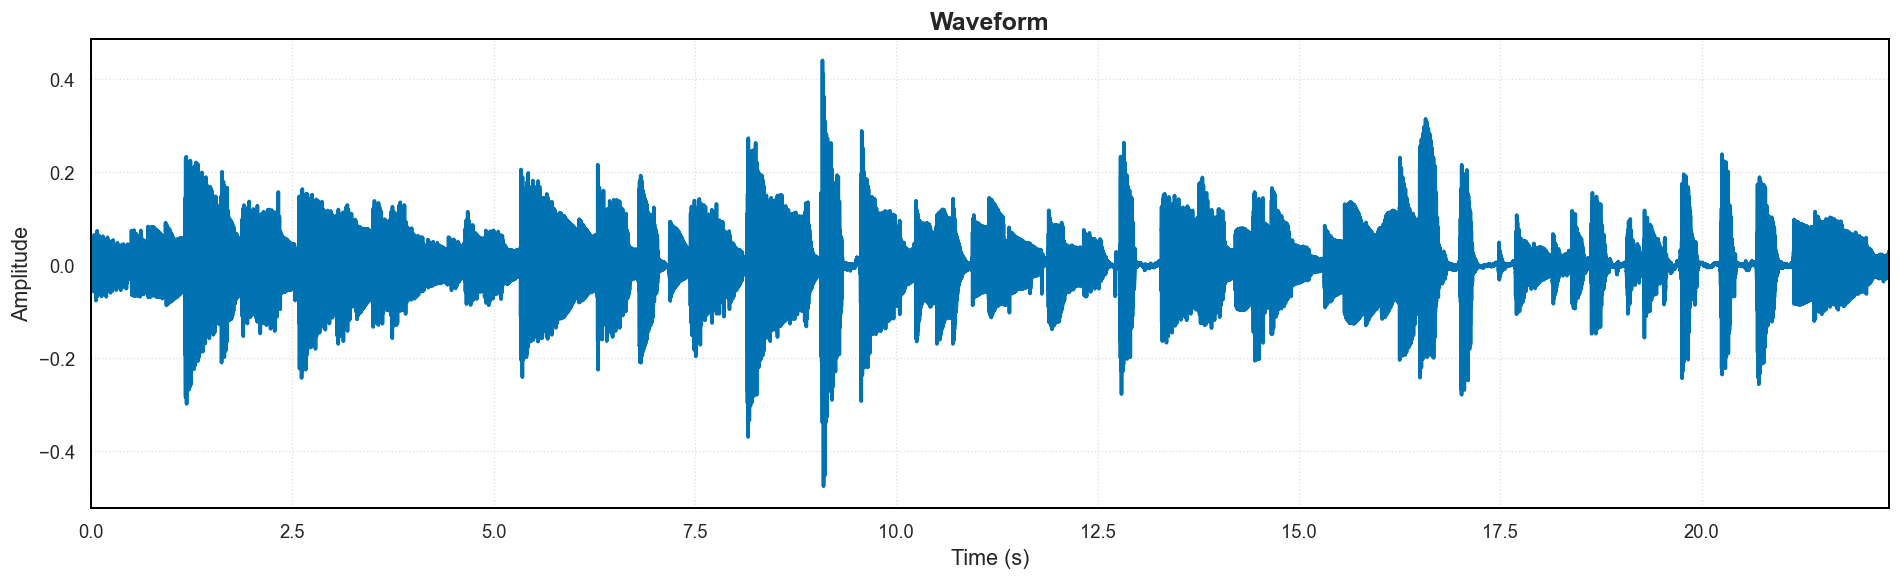

In [7]:
duration_audio = len(audio_data) / sample_rate
time_audio = np.linspace(0, duration_audio, len(audio_data))

plt.figure(figsize=(16, 5))

plt.plot(time_audio, audio_data)
plt.title("Waveform")
plt.xlabel("Time (s)")
plt.xlim((0, duration_audio))
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

In [8]:
print("Durée :                    ", duration_audio)
print("Taille d'échantillonage :  ", sample_rate)
print("Amplitude moyenne :        ", np.mean(audio_data))
print("Ecart-type de l'amplitude :", np.std(audio_data))
print("Amplitude maximale :       ", np.max(audio_data))
print("Amplitude minimale :       ", np.min(audio_data))

Durée :                     22.32439909297052
Taille d'échantillonage :   44100
Amplitude moyenne :         -0.0001437703636590648
Ecart-type de l'amplitude : 0.05107147673171689
Amplitude maximale :        0.439300537109375
Amplitude minimale :        -0.475341796875


## Chargement des classes AudioNormalizer et AudioCleaner

In [9]:
from src.transformers.audio_normalizer import AudioNormalizer, NormalizationType
from src.transformers.audio_cleaner import AudioCleaner, DenoiseMethod

audio_normalizer = AudioNormalizer(logger=logging.getLogger())
audio_cleaner = AudioCleaner(logger=logging.getLogger())

## Pipeline de prétraitement audio

### Conversion mono

La conversion d'un signal multi-canaux en mono permet de résumer l'information en un unique vecteur. L'impact est négligeable sur le modèle.

In [10]:
audio_data_mono = audio_normalizer.to_mono(audio_data=audio_data)

print(f"Nombre de canaux après conversion mono : {len(audio_data_mono.shape)}")

Nombre de canaux après conversion mono : 1


### Suppression du décallage DC

In [11]:
audio_data_without_dc_offset = audio_normalizer.remove_dc_offset(
    audio_data=audio_data_mono
)

print(f"Amplitude moyenne avant suppression du décallage DC : {audio_data_mono.mean()}")
print(
    f"Amplitude moyenne après suppression du décallage DC : {audio_data_without_dc_offset.mean()}"
)

Amplitude moyenne avant suppression du décallage DC : -0.0001437703636590648
Amplitude moyenne après suppression du décallage DC : 4.5207058779909185e-18


### Rééchantillonage

Le rééchantillonage permet de réduire le temps de calcul au détriment de la qualité de l'information. L'impact est modéré.

In [12]:
TARGET_SAMPLE_RATE = 22050

audio_data_resample, sample_rate_normalized = audio_normalizer.resample(
    audio_data=audio_data_without_dc_offset, sample_rate=TARGET_SAMPLE_RATE
)

print("Taille d'échantillonage visé                   :", TARGET_SAMPLE_RATE)
print("Taille d'échantillonage avant rééchantillonage :", sample_rate)
print("Taille d'échantillonage après rééchantillonage :", sample_rate_normalized)

Taille d'échantillonage visé                   : 22050
Taille d'échantillonage avant rééchantillonage : 44100
Taille d'échantillonage après rééchantillonage : 22050


### High-pass filter

Filtre les basses fréquences.

In [13]:
CUTOFF_HIGHT = 60  # Hz

audio_data_highpass_filtered = audio_cleaner.highpass_filter(
    audio=audio_data_resample,
    sample_rate=sample_rate_normalized,
    cutoff=CUTOFF_HIGHT,
)

print("Amplitude moyenne         :", np.mean(audio_data_highpass_filtered))
print("Ecart-type de l'amplitude :", np.std(audio_data_highpass_filtered))
print("Amplitude maximale        :", np.max(audio_data_highpass_filtered))
print("Amplitude minimale        :", np.min(audio_data_highpass_filtered))

Amplitude moyenne         : 4.423502353051867e-08
Ecart-type de l'amplitude : 0.04965931815179942
Amplitude maximale        : 0.41587604347322293
Amplitude minimale        : -0.4715795902442312


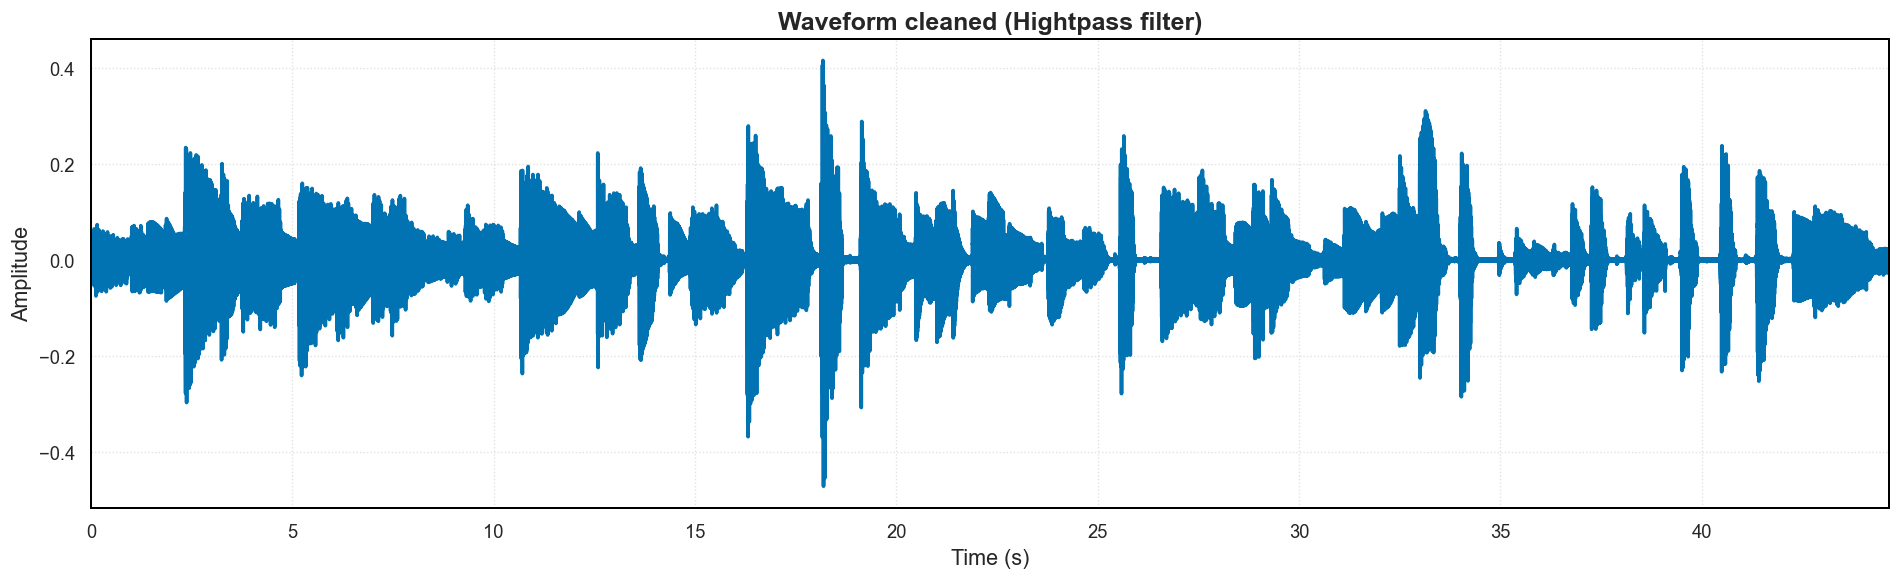

In [14]:
duration_audio_highpass_filtered = (
    len(audio_data_highpass_filtered) / sample_rate_normalized
)
time_audio_highpass_filtered = np.linspace(
    0, duration_audio_highpass_filtered, len(audio_data_highpass_filtered)
)

plt.figure(figsize=(16, 5))

plt.plot(time_audio_highpass_filtered, audio_data_highpass_filtered)
plt.title("Waveform cleaned (Hightpass filter)")
plt.xlabel("Time (s)")
plt.xlim((0, duration_audio_highpass_filtered))
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

### Low-pass filter

Filtre les hautes fréquences.

In [15]:
CUTOFF_LOW = 10_000  # Hz

audio_data_lowpass_filtered = audio_cleaner.lowpass_filter(
    audio=audio_data_highpass_filtered,
    sample_rate=sample_rate_normalized,
    cutoff=CUTOFF_LOW,
)

print("Amplitude moyenne         :", np.mean(audio_data_lowpass_filtered))
print("Ecart-type de l'amplitude :", np.std(audio_data_lowpass_filtered))
print("Amplitude maximale        :", np.max(audio_data_lowpass_filtered))
print("Amplitude minimale        :", np.min(audio_data_lowpass_filtered))

Amplitude moyenne         : 4.423633881253909e-08
Ecart-type de l'amplitude : 0.049659227885832574
Amplitude maximale        : 0.41594014231147725
Amplitude minimale        : -0.4716198918194021


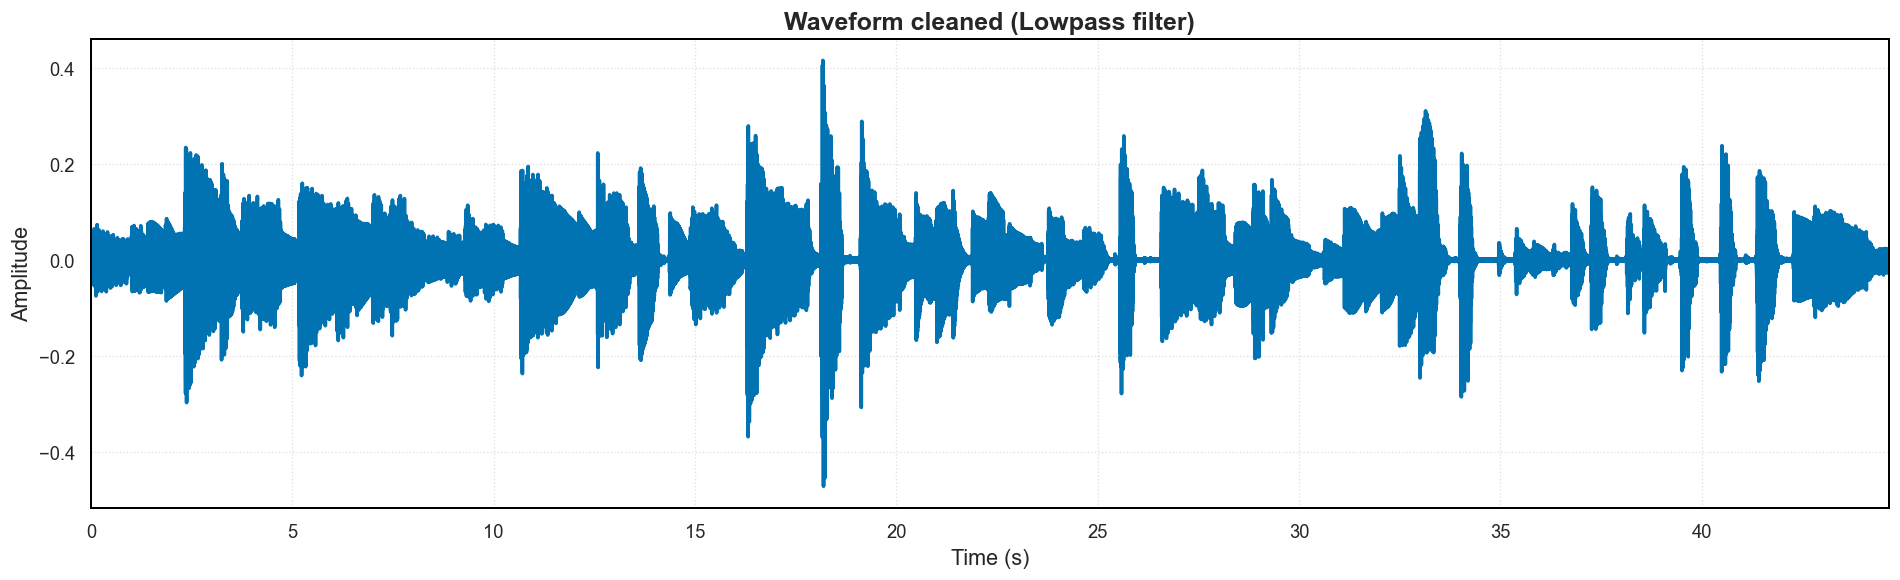

In [16]:
duration_audio_lowpass_filtered = (
    len(audio_data_lowpass_filtered) / sample_rate_normalized
)
time_audio_lowpass_filtered = np.linspace(
    0, duration_audio_lowpass_filtered, len(audio_data_lowpass_filtered)
)

plt.figure(figsize=(16, 5))

plt.plot(time_audio_lowpass_filtered, audio_data_lowpass_filtered)
plt.title("Waveform cleaned (Lowpass filter)")
plt.xlabel("Time (s)")
plt.xlim((0, duration_audio_lowpass_filtered))
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

### Spectral denoise

Supprime le bruit avec une méthode spectrale.

In [17]:
audio_data_spectral_denoise = audio_cleaner.spectral_denoise(
    audio=audio_data_lowpass_filtered
)

print("Amplitude moyenne         :", np.mean(audio_data_spectral_denoise))
print("Ecart-type de l'amplitude :", np.std(audio_data_spectral_denoise))
print("Amplitude maximale        :", np.max(audio_data_spectral_denoise))
print("Amplitude minimale        :", np.min(audio_data_spectral_denoise))

Amplitude moyenne         : -1.3190225408973391e-08
Ecart-type de l'amplitude : 0.04443550041022275
Amplitude maximale        : 0.39876878775908015
Amplitude minimale        : -0.4616558599913807


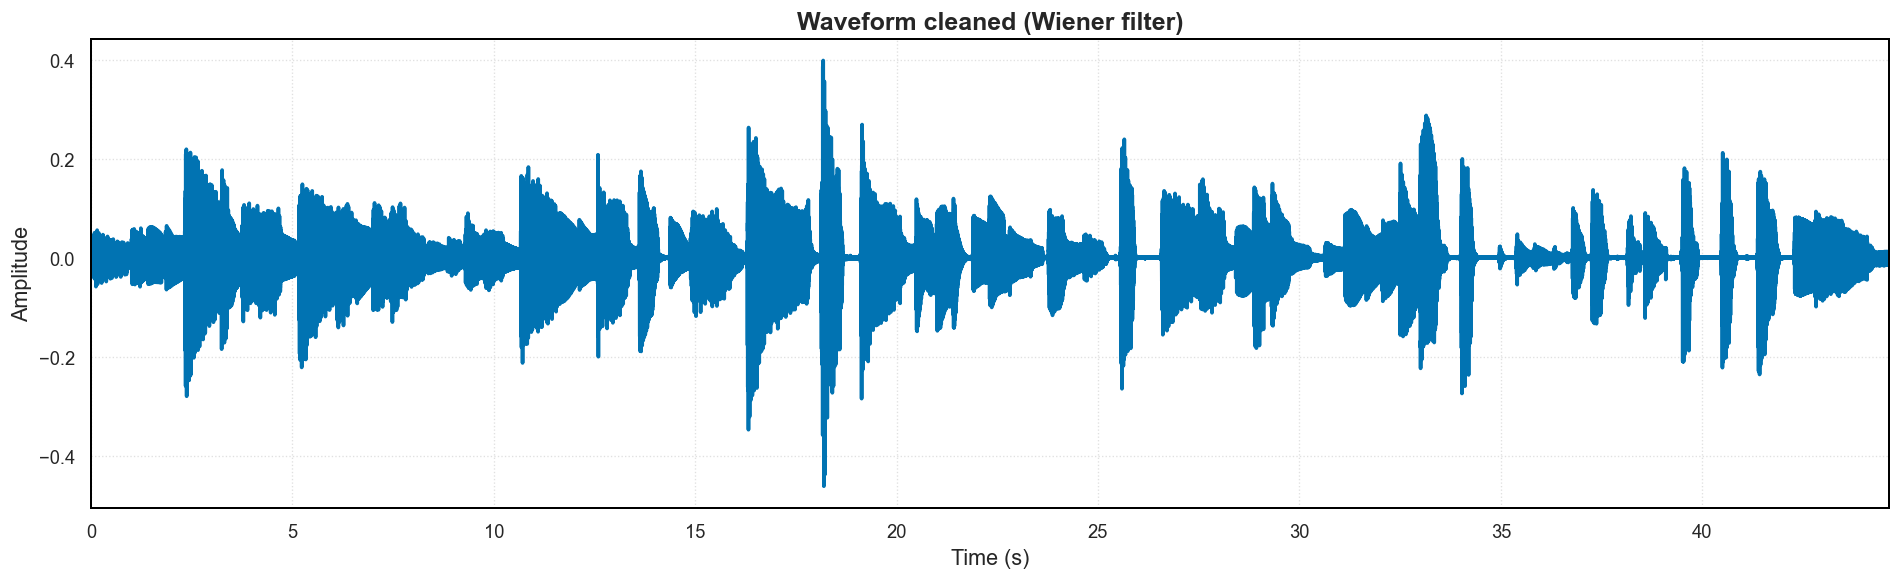

In [18]:
duration_audio_spectral_denoise = (
    len(audio_data_spectral_denoise) / sample_rate_normalized
)
time_audio_spectral_denoise = np.linspace(
    0, duration_audio_spectral_denoise, len(audio_data_spectral_denoise)
)

plt.figure(figsize=(16, 5))

plt.plot(time_audio_spectral_denoise, audio_data_spectral_denoise)
plt.title("Waveform cleaned (Wiener filter)")
plt.xlabel("Time (s)")
plt.xlim((0, duration_audio_spectral_denoise))
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

### Wiener denoise

Supprime le bruit.

In [19]:
NOISE_REDUCTION_FACTOR = 10

audio_data_wiener_filtered = audio_cleaner.wiener_denoise(
    audio=audio_data_lowpass_filtered, strength=NOISE_REDUCTION_FACTOR
)

print("Amplitude moyenne         :", np.mean(audio_data_wiener_filtered))
print("Ecart-type de l'amplitude :", np.std(audio_data_wiener_filtered))
print("Amplitude maximale        :", np.max(audio_data_wiener_filtered))
print("Amplitude minimale        :", np.min(audio_data_wiener_filtered))

Amplitude moyenne         : -2.974417597394337e-08
Ecart-type de l'amplitude : 0.04910986987511184
Amplitude maximale        : 0.41541017270878583
Amplitude minimale        : -0.4714982487873797


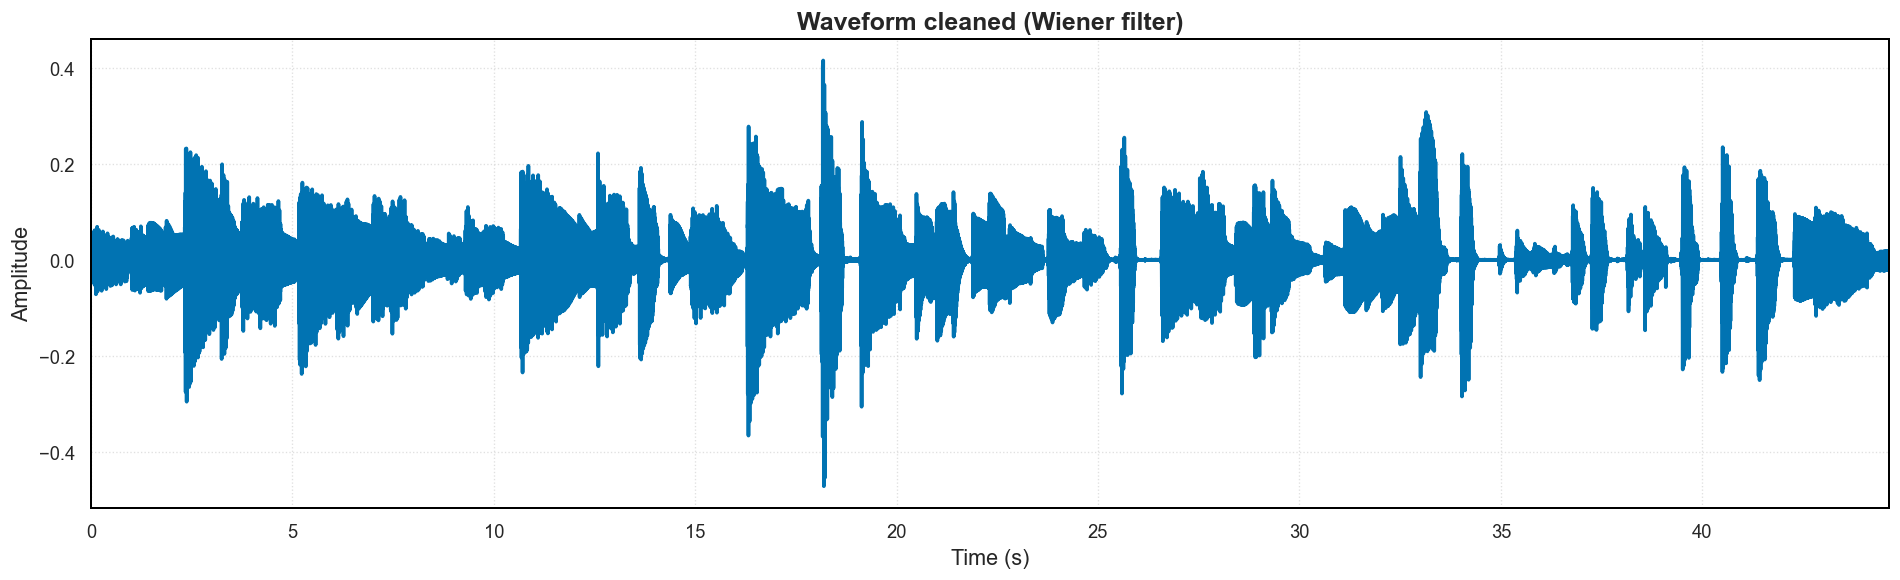

In [20]:
duration_audio_wiener_filtered = (
    len(audio_data_wiener_filtered) / sample_rate_normalized
)
time_audio_wiener_filtered = np.linspace(
    0, duration_audio_wiener_filtered, len(audio_data_wiener_filtered)
)

plt.figure(figsize=(16, 5))

plt.plot(time_audio_wiener_filtered, audio_data_wiener_filtered)
plt.title("Waveform cleaned (Wiener filter)")
plt.xlabel("Time (s)")
plt.xlim((0, duration_audio_wiener_filtered))
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

In [21]:
audio_data_denoised = audio_data_spectral_denoise

### Silence trimming

Supprime les silences au début et à la fin de l'audio. Non utilisé pour sur les datasets GuitarSet et IDMT-SMT-Guitar pour ne pas décaller l'alignement avec les annotations.

In [22]:
TOP_DB = 60

audio_data_trimmed = audio_cleaner.trim_silence(
    audio=audio_data_denoised, top_db=TOP_DB
)

duration_audio_normalized = len(audio_data_resample) / sample_rate_normalized
duration_audio_trimmed = len(audio_data_denoised) / sample_rate_normalized

print("Durée audio normalisé :", duration_audio_normalized)
print("Durée audio nettoyé   :", duration_audio_trimmed)

Durée audio normalisé : 44.64879818594104
Durée audio nettoyé   : 44.62875283446712


### Normalisation Peak vs RMS vs Peak+RMS

Normalisation
- peak : amplitude entre -1 et 1.
- RMS : basé sur l'énergie.
- peak + RMS : dans cet ordre.

In [23]:
TARGET_PEAK = 0.99

audio_data_peak = audio_normalizer.normalize(
    audio_data=audio_data_denoised,
    normalization_type=NormalizationType.PEAK,
    target_peak=TARGET_PEAK,
)

print("Amplitude moyenne         :", np.mean(audio_data_peak))
print("Ecart-type de l'amplitude :", np.std(audio_data_peak))
print("Amplitude maximale        :", np.max(audio_data_peak))
print("Amplitude minimale        :", np.min(audio_data_peak))

Amplitude moyenne         : -2.8285838622546827e-08
Ecart-type de l'amplitude : 0.09528991012253554
Amplitude maximale        : 0.8551415331083636
Amplitude minimale        : -0.9900000000000001


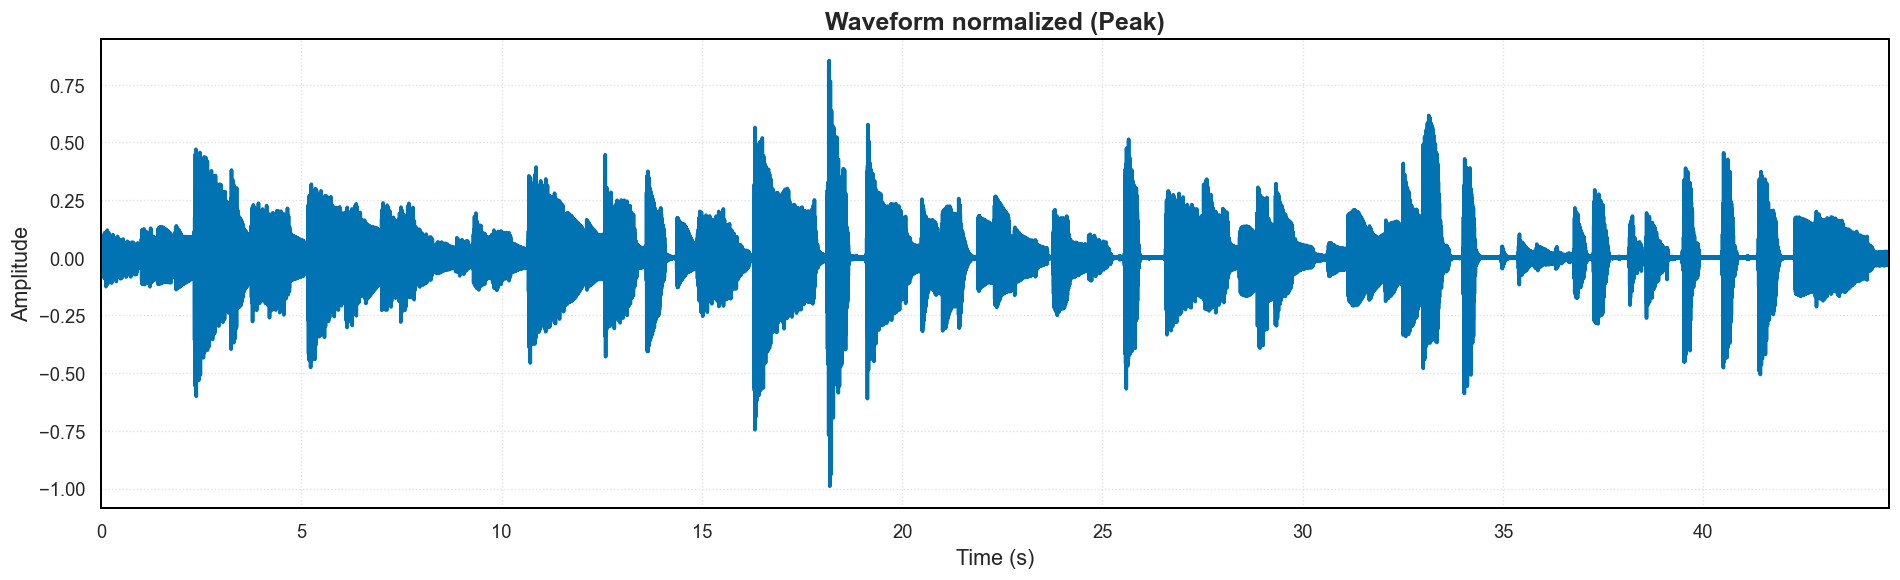

In [24]:
duration_audio_peak = len(audio_data_peak) / sample_rate_normalized
time_audio_peak = np.linspace(0, duration_audio_peak, len(audio_data_peak))

plt.figure(figsize=(16, 5))

plt.plot(time_audio_peak, audio_data_peak)
plt.title("Waveform normalized (Peak)")
plt.xlabel("Time (s)")
plt.xlim((0, duration_audio_peak))
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

In [25]:
TARGET_RMS = 0.1

audio_data_rms = audio_normalizer.normalize(
    audio_data=audio_data_denoised,
    normalization_type=NormalizationType.RMS,
    target_rms=TARGET_RMS,
)

print("Amplitude moyenne         :", np.mean(audio_data_rms))
print("Ecart-type de l'amplitude :", np.std(audio_data_rms))
print("Amplitude maximale        :", np.max(audio_data_rms))
print("Amplitude minimale        :", np.min(audio_data_rms))

Amplitude moyenne         : -2.9683980797300308e-08
Ecart-type de l'amplitude : 0.09999999999999559
Amplitude maximale        : 0.8974103680113449
Amplitude minimale        : -1.0389347610118345


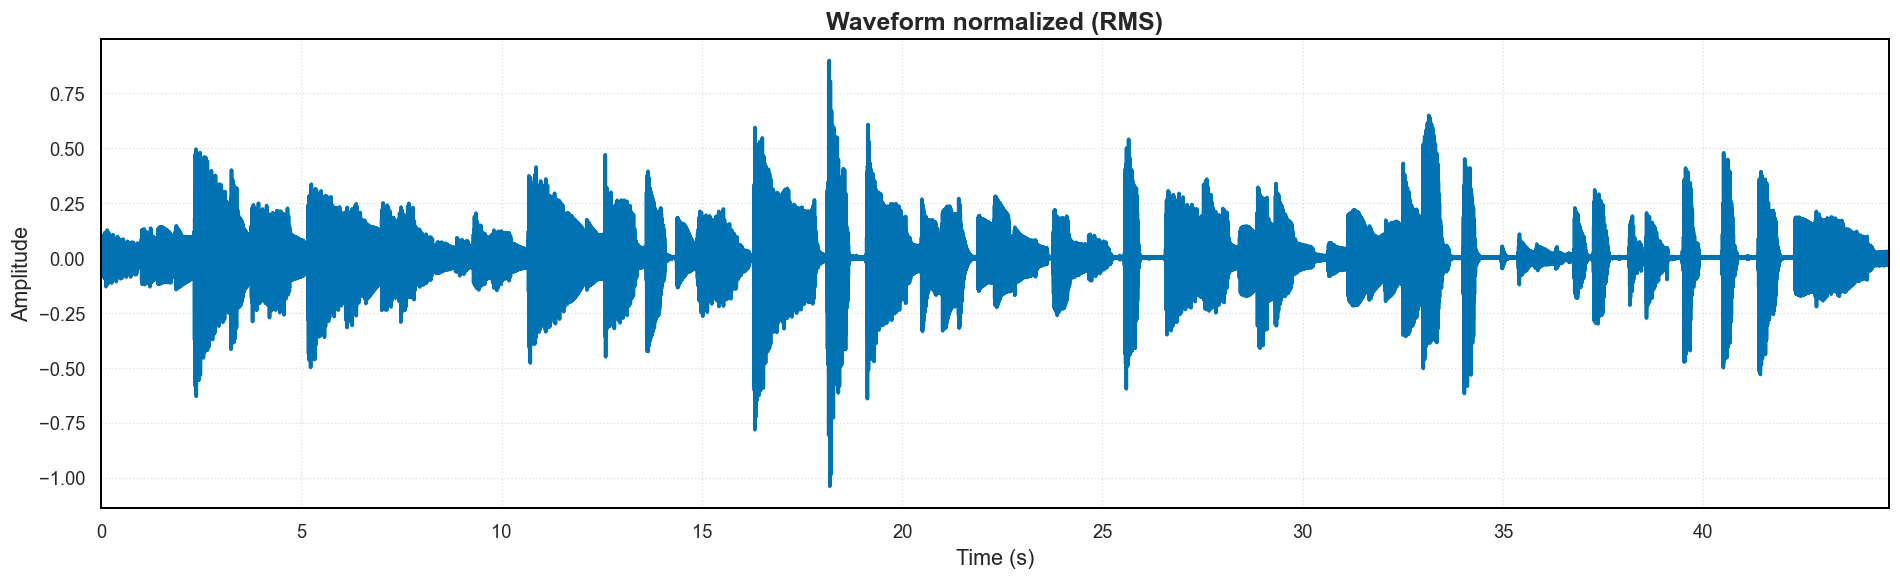

In [26]:
duration_audio_rms = len(audio_data_rms) / sample_rate_normalized
time_audio_rms = np.linspace(0, duration_audio_rms, len(audio_data_rms))

plt.figure(figsize=(16, 5))

plt.plot(time_audio_rms, audio_data_rms)
plt.title("Waveform normalized (RMS)")
plt.xlabel("Time (s)")
plt.xlim((0, duration_audio_rms))
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

In [27]:
audio_data_peak_rms = audio_normalizer.normalize(
    audio_data=audio_data_denoised,
    normalization_type=NormalizationType.PEAK_RMS,
    target_peak=TARGET_PEAK,
    target_rms=TARGET_RMS,
)

print("Amplitude moyenne         :", np.mean(audio_data_peak_rms))
print("Ecart-type de l'amplitude :", np.std(audio_data_peak_rms))
print("Amplitude maximale        :", np.max(audio_data_peak_rms))
print("Amplitude minimale        :", np.min(audio_data_peak_rms))

Amplitude moyenne         : -2.9683980797296698e-08
Ecart-type de l'amplitude : 0.0999999999999956
Amplitude maximale        : 0.8974103680113449
Amplitude minimale        : -1.0389347610118345


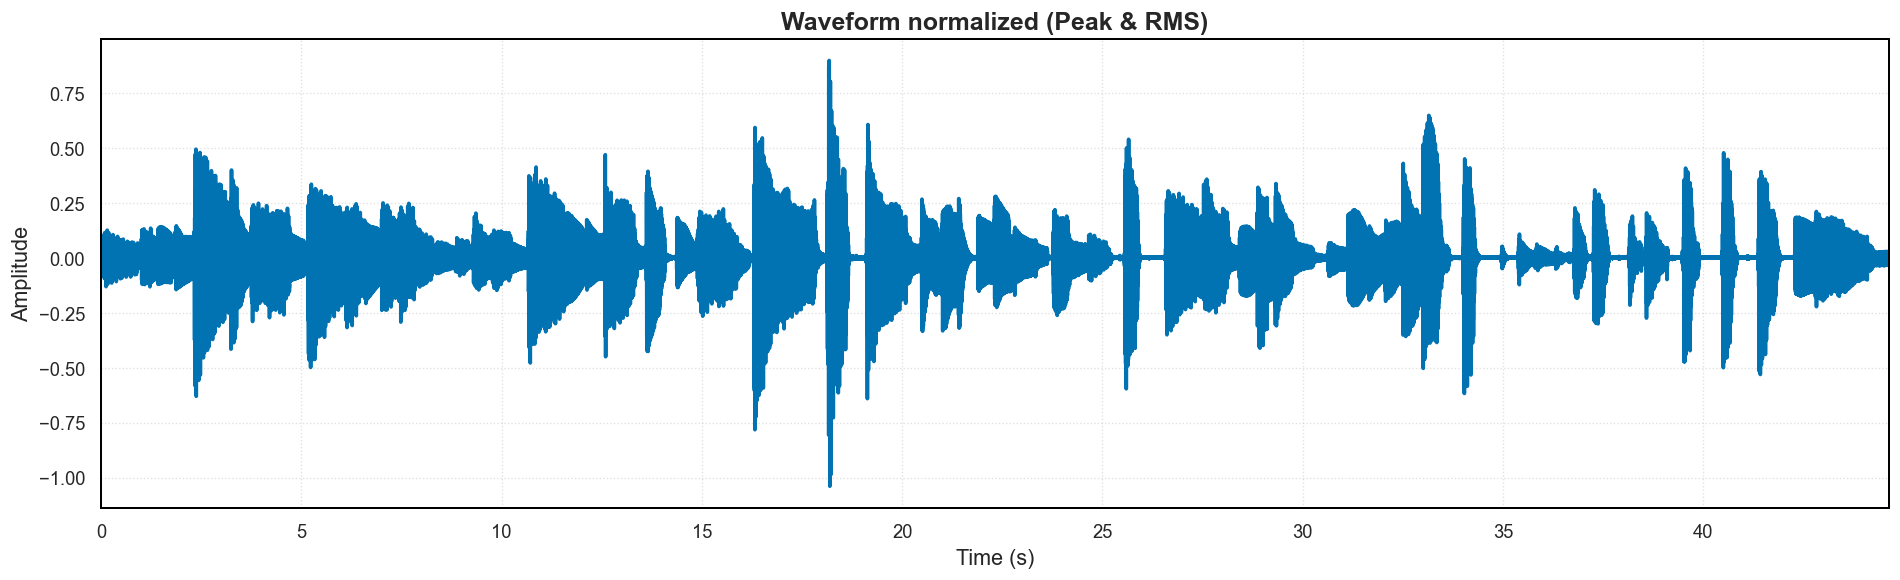

In [28]:
duration_audio_peak_rms = len(audio_data_peak_rms) / sample_rate_normalized
time_audio_peak_rms = np.linspace(0, duration_audio_peak_rms, len(audio_data_peak_rms))

plt.figure(figsize=(16, 5))

plt.plot(time_audio_peak_rms, audio_data_peak_rms)
plt.title("Waveform normalized (Peak & RMS)")
plt.xlabel("Time (s)")
plt.xlim((0, duration_audio_peak_rms))
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

In [29]:
audio_data_normalized = audio_data_rms

### Cast float32

In [30]:
audio_data_float32 = audio_normalizer.to_float32(audio_data=audio_data_normalized)

print("Audio data dtype avant cast float32 dtype :", audio_data_normalized.dtype)
print("Audio data dtype aprés cast float32 dtype :", audio_data_float32.dtype)

Audio data dtype avant cast float32 dtype : float64
Audio data dtype aprés cast float32 dtype : float32
